In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim


import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import itertools
import cupy as cp

In [19]:

from src.metrics import Metrics

In [20]:
SEED = 42

In [21]:
X_images = cp.load("data/X_images.npy")
y_images = cp.load("data/y_images.npy")

from src.data_splitting import split_data

X_dev, y_dev, X_test, y_test = split_data(X_images, y_images, ratio=0.2, seed=SEED)
X_train, y_train, X_val, y_val = split_data(X_dev, y_dev, ratio=0.2, seed=SEED)


X_train = X_train.astype(cp.float32) / 255.0
X_val   = X_val.astype(cp.float32)   / 255.0
X_test  = X_test.astype(cp.float32)  / 255.0
X_dev   = X_dev.astype(cp.float32)   / 255.0


Epoch 001 | Val Loss: 3.6002 | Acc: 0.1050 | CE: 3.6002
Epoch 002 | Val Loss: 3.0590 | Acc: 0.2350 | CE: 3.0590
Epoch 003 | Val Loss: 2.7030 | Acc: 0.3038 | CE: 2.7030
Epoch 004 | Val Loss: 2.5068 | Acc: 0.3675 | CE: 2.5068
Epoch 005 | Val Loss: 2.2819 | Acc: 0.3900 | CE: 2.2819
Epoch 006 | Val Loss: 2.2108 | Acc: 0.4150 | CE: 2.2108
Epoch 007 | Val Loss: 2.1169 | Acc: 0.4250 | CE: 2.1169
Epoch 008 | Val Loss: 2.0239 | Acc: 0.4550 | CE: 2.0239
Epoch 009 | Val Loss: 1.9921 | Acc: 0.4688 | CE: 1.9921
Epoch 010 | Val Loss: 1.8368 | Acc: 0.5312 | CE: 1.8368
Epoch 011 | Val Loss: 1.8480 | Acc: 0.5312 | CE: 1.8480
Epoch 012 | Val Loss: 1.7961 | Acc: 0.5225 | CE: 1.7961
Epoch 013 | Val Loss: 1.8401 | Acc: 0.5100 | CE: 1.8401
Epoch 014 | Val Loss: 1.7616 | Acc: 0.5425 | CE: 1.7616
Epoch 015 | Val Loss: 1.7536 | Acc: 0.5450 | CE: 1.7536
Epoch 016 | Val Loss: 1.7231 | Acc: 0.5475 | CE: 1.7231
Epoch 017 | Val Loss: 1.7126 | Acc: 0.5475 | CE: 1.7126
Epoch 018 | Val Loss: 1.7886 | Acc: 0.5350 | CE:

C:\Users\anapt\AppData\Local\Temp\ipykernel_35868\832744400.py:148: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


### Desempeño Final en Validación
**Accuracy:** **0.6250**  
**Cross-Entropy Loss:** 1.6364  


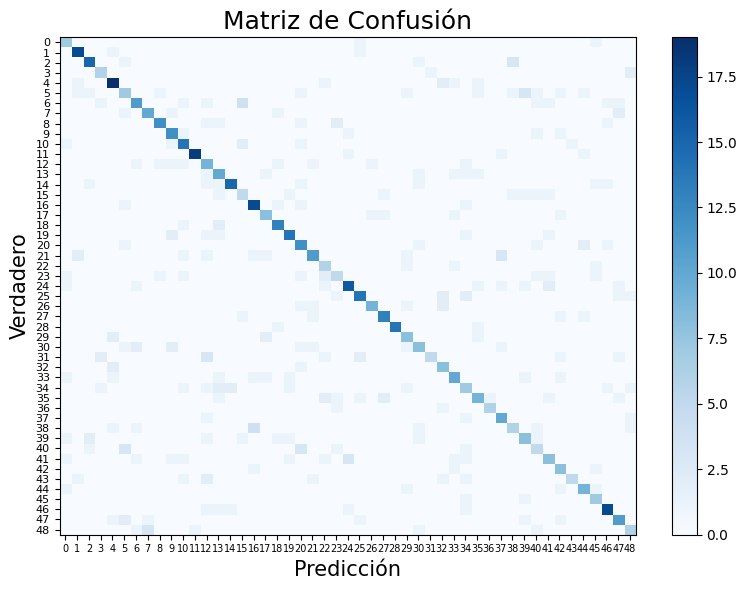

>> Entrenamiento y evaluación completados.


In [ ]:

# ----------------------------
# 1) Parámetros y configuración
# ----------------------------
# X_train: (n_train, n_features), y_train: (n_train,)
# X_val  : (n_val,   n_features), y_val  : (n_val,)

input_size = X_train.shape[1]
n_classes  = int(cp.max(y_train)) + 1
epochs     = 400

best_conf = {
    'arch':          [input_size, 128, 64, 32, n_classes],
    'optimizer':     'adam',
    'batch_size':    1024,
    'learning_rate': 0.01,
    'l2_lambda':     1e-3,
    'dropout_p':     0.2,
    'use_batchnorm': False,
    'early_stopping': True,
    'patience':       20,
    'lr_schedule':    'none',  # 'none', 'linear', 'exp'
}

# ----------------------------
# 2) Definición del modelo MLP
# ----------------------------
class MLPClassifier(nn.Module):
    def __init__(self, conf):
        super().__init__()
        layers = []
        sizes = conf['arch']         # [in, h1, h2, ..., out]
        for i in range(len(sizes) - 1):
            in_dim  = sizes[i]
            out_dim = sizes[i+1]
            layers.append(nn.Linear(in_dim, out_dim))
            if i < len(sizes) - 2:  # solo en capas ocultas
                if conf['use_batchnorm']:
                    layers.append(nn.BatchNorm1d(out_dim))
                layers.append(nn.ReLU())
                if conf['dropout_p'] > 0:
                    layers.append(nn.Dropout(conf['dropout_p']))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ----------------------------
# 3) DataLoaders
# ----------------------------
def get_dataloader(X, y, batch_size):
    X_t = torch.tensor(cp.asnumpy(X), dtype=torch.float32)
    y_t = torch.tensor(cp.asnumpy(y), dtype=torch.long)
    ds  = torch.utils.data.TensorDataset(X_t, y_t)
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

train_loader = get_dataloader(X_train, y_train, best_conf['batch_size'])
val_loader   = get_dataloader(X_val,   y_val,   best_conf['batch_size'])

# ----------------------------
# 4) Inicialización
# ----------------------------
model     = MLPClassifier(best_conf)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=best_conf['learning_rate'],
    weight_decay=best_conf['l2_lambda']
)

# Scheduler opcional
if best_conf['lr_schedule'] == 'linear':
    scheduler = optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=1.0,
        end_factor=0.0,
        total_iters=best_conf['patience'] * len(train_loader)
    )
elif best_conf['lr_schedule'] == 'exp':
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
else:
    scheduler = None

# ----------------------------
# 5) Bucle de entrenamiento
# ----------------------------
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, epochs + 1):
    # --- entrenamiento ---
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        if scheduler:
            scheduler.step()

    # --- validación ---
    model.eval()
    val_loss   = 0.0
    all_preds  = []
    all_probs  = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)

            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            # Movemos todo a CPU y luego a CuPy
            all_probs.append(cp.array(probs.cpu().numpy()))
            all_preds.append(cp.array(preds.cpu().numpy()))
            all_labels.append(cp.array(y_batch.cpu().numpy()))

    val_loss /= len(val_loader.dataset)

    # Concatenar con CuPy
    y_true = cp.concatenate(all_labels)
    y_pred = cp.concatenate(all_preds)
    y_proba = cp.concatenate(all_probs)

    # Métricas con tu clase Metrics
    m   = Metrics(y_true, y_pred, y_proba)
    acc = m.accuracy()
    ce  = m.cross_entropy()
    print(f"Epoch {epoch:03d} | Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | CE: {ce:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if best_conf['early_stopping'] and patience_counter >= best_conf['patience']:
            print(f"Early stopping en epoch {epoch}.")
            break

# ----------------------------
# 6) Evaluación final
# ----------------------------
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

with torch.no_grad():
    X_val_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits  = model(X_val_t)
    probs   = torch.softmax(logits, dim=1)
    preds   = probs.argmax(dim=1)
    y_proba = cp.array(probs.cpu().numpy())
    y_pred  = cp.array(preds.cpu().numpy())
    y_true  = y_val  # ya era un array de CuPy

m_final = Metrics(y_true, y_pred, y_proba)
m_final.report_metrics(title="Desempeño Final en Validación")

print(">> Entrenamiento y evaluación completados.")
